In [80]:
%matplotlib widget
%matplotlib widget
import os
from pathlib import Path
import time
import torch
import numpy as np
import math
import gc
from functools import partial
from dataset_alt import Dataset, load_dataframes_from_folder, reverse_normalization
from torch.utils.data import DataLoader
from transformer_zerostep import GPTConfig, GPT, warmup_cosine_lr
import argparse
import warnings
import matplotlib.pyplot as plt
import copy
import pandas as pd


# set figure parameters
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['axes.labelsize']=14
plt.rcParams['xtick.labelsize']=11
plt.rcParams['ytick.labelsize']=11
# plt.rcParams['axes.grid']=True
plt.rcParams['axes.xmargin']=0

In [81]:

file_name = "motors_maxon.csv"
current_path = os.getcwd().split("in-context-bldc")[0]
data_path = os.path.join(current_path,"in-context-bldc", "data", "other")
file_path = os.path.join(data_path, file_name)

df_motors = pd.read_csv(file_path)

In [82]:
# df_motors["Number of Pole Pairs"].to_numpy()
df_motors.keys()

Index(['Motor Name', 'Nominal Voltage (V)', 'Nominal Current (A)',
       'Nominal Power (W)', 'Nominal Speed (rpm)', 'Nominal Torque (mNm)',
       'Terminal Resistance (Ω)', 'Terminal Inductance (mH)',
       'Torque Constant (mNm/A)', 'Speed Constant (rpm/V)',
       'Rotor Inertia (gcm²)', 'Number of Pole Pairs'],
      dtype='object')

In [83]:
df_motors['Calculated Nominal Power (W)'] = df_motors['Nominal Torque (mNm)'] * \
                                    df_motors['Nominal Speed (rpm)'] * (np.pi / 30000)

In [84]:
(df_motors['Calculated Nominal Power (W)'].to_numpy() - df_motors['Nominal Power (W)'].to_numpy()) / df_motors['Nominal Power (W)'].to_numpy()

array([-0.41966406, -0.66462451, -0.23357706, -0.55511906,  0.50795749,
       -0.35427006, -0.30570802,  0.16193899, -0.35542985, -0.36884958,
        0.25282788, -0.03315284, -0.05435125,  0.10394257, -0.06720467,
       -0.04377157,  0.41078454, -0.05500893, -0.13056423, -0.13415961,
        0.51228731,  0.04645288, -0.01088701, -0.01664659,  0.49414147,
       -0.06801512, -0.10994491, -0.12834941,  1.60525996,  1.78973428,
        1.85172837,  0.09252026,  0.02541778,  0.01518239, -0.04889252,
        0.01380452, -0.16507784, -0.17719662, -0.21853389,  0.01380452,
       -0.12262417, -0.13535916, -0.17879833,  0.02258841, -0.0232122 ,
        0.01136435, -0.05763644,  0.10828844, -0.09822049, -0.10528698,
       -0.09936612,  0.09065101, -0.07595943, -0.18158675, -0.15726777,
        0.09065101, -0.26076754, -0.3452694 , -0.32581422,  0.01664818,
       -0.0426179 ,  0.0086071 ,  0.04084618,  0.17678825,  0.05691509,
        0.01269633, -0.02675937,  0.20165919, -0.02458123, -0.05

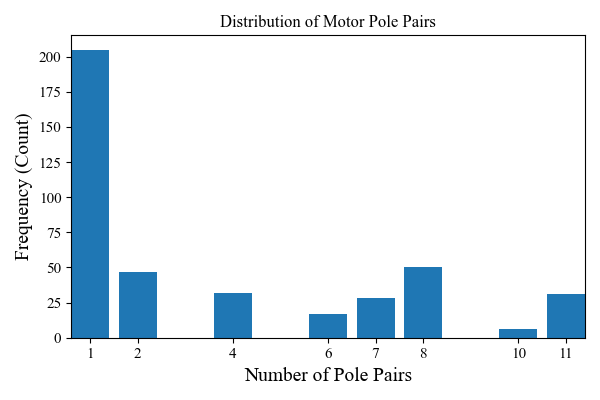

In [93]:
pole_counts = df_motors['Number of Pole Pairs'].value_counts().sort_index()

fig = plt.figure(figsize=(6,4))
ax0 = fig.add_subplot()
# ax0.hist(df_motors["Number of Pole Pairs"].to_numpy())
ax0.bar(pole_counts.index, pole_counts.values)
plt.title('Distribution of Motor Pole Pairs')
plt.xlabel('Number of Pole Pairs')
plt.ylabel('Frequency (Count)')
plt.xticks(pole_counts.index)
plt.grid(False)
plt.tight_layout()
plt.savefig("figs_maxon/PP_distribution.png")
plt.show()


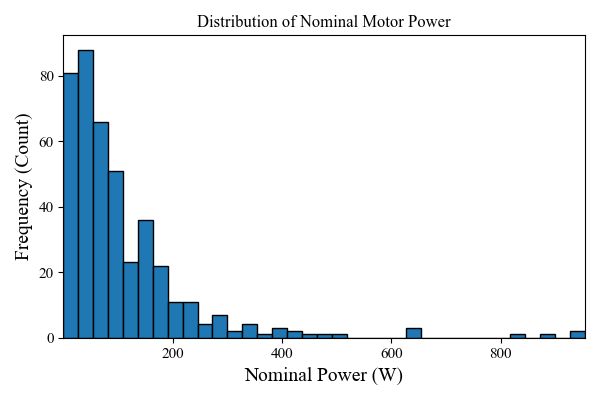

In [92]:
plt.figure(figsize=(6, 4))
# 'bins='auto'' lets matplotlib find a reasonable number of bins
plt.hist(df_motors['Calculated Nominal Power (W)'], bins='auto', edgecolor='black')

# Add titles and labels
plt.title('Distribution of Nominal Motor Power')
plt.xlabel('Nominal Power (W)')
plt.ylabel('Frequency (Count)')
# plt.grid(axis='y', alpha=0.7)
plt.grid(False)
plt.tight_layout()
plt.savefig("figs_maxon/power_distribution.png")
plt.show()

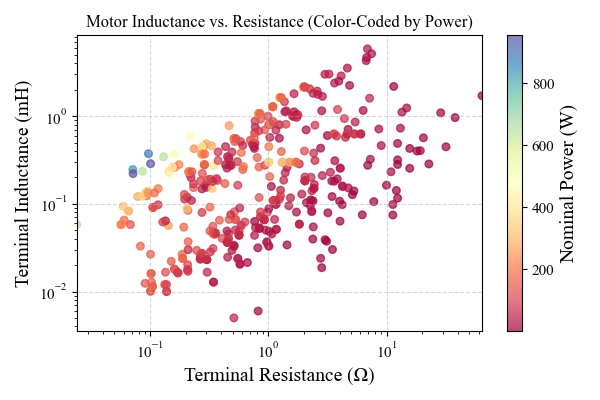

In [94]:
plt.figure(figsize=(6, 4)) # Make the figure a bit larger
scatter = plt.scatter(
    x=df_motors['Terminal Resistance (Ω)'],
    y=df_motors['Terminal Inductance (mH)'],
    c=df_motors['Calculated Nominal Power (W)'], # Color-code based on calculated power
    cmap='Spectral',                       # 'viridis', 'plasma', or 'coolwarm' are good choices
    alpha=0.7,                            # Add transparency for overlapping points
    s=30                                  # Set a default dot size
)

# Add titles and labels
plt.title('Motor Inductance vs. Resistance (Color-Coded by Power)')
plt.xlabel('Terminal Resistance (Ω)')
plt.ylabel('Terminal Inductance (mH)')
plt.xscale('log')
plt.yscale('log')

# Add a color bar to show the power scale
cbar = plt.colorbar(scatter)
cbar.set_label('Nominal Power (W)')

# Add a grid for easier reading
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("figs_maxon/RL_power.png")
plt.show()

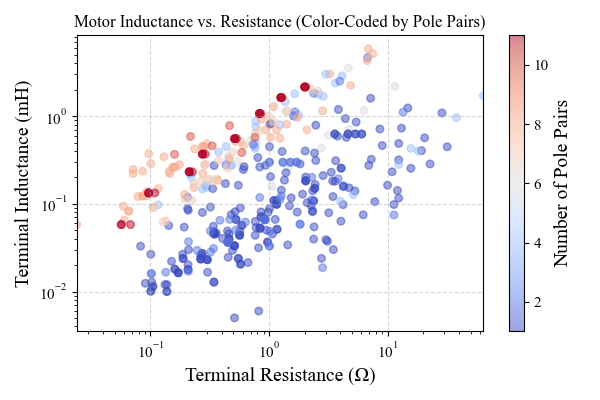

In [95]:
plt.figure(figsize=(6, 4)) 
scatter = plt.scatter(
    x=df_motors['Terminal Resistance (Ω)'],
    y=df_motors['Terminal Inductance (mH)'],
    c=df_motors['Number of Pole Pairs'], # Color-code based on calculated power
    cmap='coolwarm',                       # 'viridis', 'plasma', or 'coolwarm' are good choices
    alpha=0.5,                            # Add transparency for overlapping points
    s=30                                  # Set a default dot size
)

# Add titles and labels
plt.title('Motor Inductance vs. Resistance (Color-Coded by Pole Pairs)')
plt.xlabel('Terminal Resistance (Ω)')
plt.ylabel('Terminal Inductance (mH)')
plt.xscale('log')
plt.yscale('log')

# Add a color bar to show the power scale
cbar = plt.colorbar(scatter)
cbar.set_label('Number of Pole Pairs')

# Add a grid for easier reading
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("figs_maxon/RL_PP.png")
plt.show()

In [89]:
# Method 1: From Speed Constant (Kv)
# lambda_m = (1 / P) * ( (1 / Kv) * (30 / pi) )
df_motors['Flux_Linkage_from_Kv (Wb)'] = (1 / df_motors['Number of Pole Pairs']) * \
                                 (1 / df_motors['Speed Constant (rpm/V)']) * \
                                 (30 / np.pi)

# Method 2: From Torque Constant (Kt)
# lambda_m = (Kt_mNm / 1000) / P
df_motors['Flux_Linkage_from_Kt (Wb)'] = df_motors['Torque Constant (mNm/A)'] / \
                                 (1000 * df_motors['Number of Pole Pairs'])

# Display a comparison of the two calculations
print(df_motors[['Motor Name', 
          'Flux_Linkage_from_Kv (Wb)', 
          'Flux_Linkage_from_Kt (Wb)']].head())


           Motor Name  Flux_Linkage_from_Kv (Wb)  Flux_Linkage_from_Kt (Wb)
0  ECX SPEED 4 M (3V)                   0.000764                   0.000763
1  ECX SPEED 4 M (6V)                   0.001530                   0.001530
2  ECX SPEED 4 L (3V)                   0.000764                   0.000763
3  ECX SPEED 4 L (6V)                   0.001530                   0.001530
4  ECX SPEED 6 M (3V)                   0.000370                   0.000370


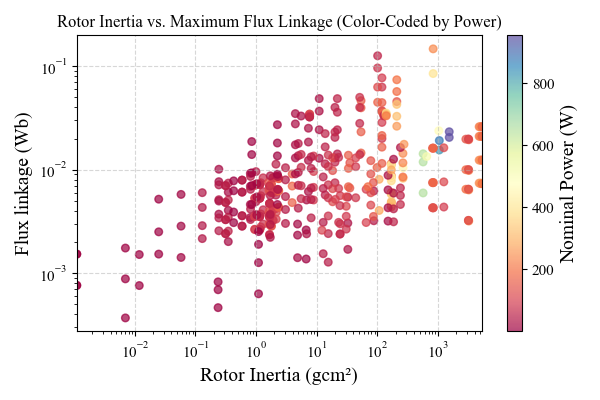

In [96]:
plt.figure(figsize=(6, 4)) # Make the figure a bit larger
scatter = plt.scatter(
    x=df_motors['Rotor Inertia (gcm²)'],
    y=df_motors['Flux_Linkage_from_Kt (Wb)'],
    c=df_motors['Calculated Nominal Power (W)'], # Color-code based on calculated power
    cmap='Spectral',                       # 'viridis', 'plasma', or 'coolwarm' are good choices
    alpha=0.7,                            # Add transparency for overlapping points
    s=30                                  # Set a default dot size
)

# Add titles and labels
plt.title('Rotor Inertia vs. Maximum Flux Linkage (Color-Coded by Power)')
plt.xlabel('Rotor Inertia (gcm²)')
plt.ylabel('Flux linkage (Wb)')
plt.xscale('log')
plt.yscale('log')

# Add a color bar to show the power scale
cbar = plt.colorbar(scatter)
cbar.set_label('Nominal Power (W)')

# Add a grid for easier reading
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("figs_maxon/I_flux_power.png")
plt.show()



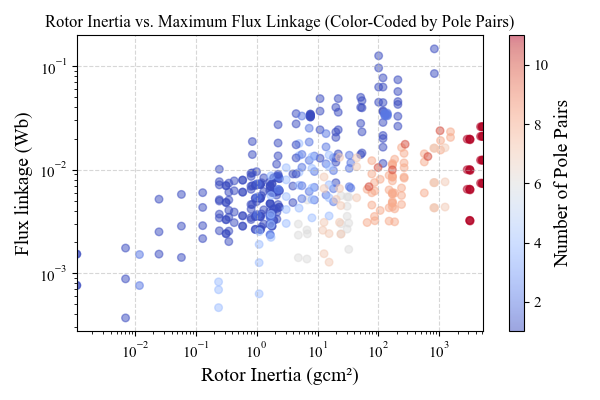

In [97]:

plt.figure(figsize=(6, 4)) # Make the figure a bit larger
scatter = plt.scatter(
    x=df_motors['Rotor Inertia (gcm²)'],
    y=df_motors['Flux_Linkage_from_Kt (Wb)'],
    c=df_motors['Number of Pole Pairs'], # Color-code based on calculated power
    cmap='coolwarm',                       # 'viridis', 'plasma', or 'coolwarm' are good choices
    alpha=0.5,                            # Add transparency for overlapping points
    s=30                                  # Set a default dot size
)

# Add titles and labels
plt.title('Rotor Inertia vs. Maximum Flux Linkage (Color-Coded by Pole Pairs)')
plt.xlabel('Rotor Inertia (gcm²)')
plt.ylabel('Flux linkage (Wb)')
plt.xscale('log')
plt.yscale('log')

# Add a color bar to show the power scale
cbar = plt.colorbar(scatter)
cbar.set_label('Number of Pole Pairs')

# Add a grid for easier reading
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("figs_maxon/I_Flux_PP.png")
plt.show()